# ✅ Solutions — Module 12 — Bayesian Statistics

Worked solutions for every exercise of this module. **Try the exercise yourself first** — you learn statistics by *doing* it. Each solution ends with a short interpretation, because in real projects the numbers are only half of the answer.

*Every exercise is self-contained: run the setup cell below, then jump to any exercise.*

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
from scipy.special import gammaln
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

def hdi(samples, mass=.95):
    """Highest-density interval: the narrowest interval containing `mass` of the posterior draws."""
    s = np.sort(samples); m = int(np.ceil(mass * s.size)); widths = s[m - 1:] - s[:s.size - m + 1]; i = widths.argmin()
    return s[i], s[i + m - 1]

### ✍️ Exercise 12.1 — *Beta–Binomial with an informative prior*: Early read-out of a product launch (Start-up analytics)

A start-up has launched a new subscription product. After two days: **3 purchases among 40 visitors**. The founders cheer about "7.5 % conversion". From a dozen earlier launches the team knows that conversion rates typically lie around 4 %, summarised as a Beta(4, 96) prior.

**Tasks**
1. Compute the posterior under the informative prior and under a flat Beta(1, 1) prior: mean, 95 % credible interval, and $P(\theta>5\,\%)$. Compare with the frequentist Wilson interval.
2. Plot prior and both posteriors.
3. Three weeks later the counts are **62 purchases among 1,000 visitors**. Repeat the analysis. What happened to the influence of the prior?
4. Which analysis would you have shown the investors after two days — and why?

In [2]:
prior_inf, prior_flat = (4, 96), (1, 1)
early, later = (3, 40), (62, 1000)                 # (purchases, visitors)

after 2 days: 3 / 40
                         posterior mean  2.5 %  97.5 %  P(θ > 5 %)
informative Beta(4, 96)           0.050  0.020   0.092       0.454
flat Beta(1, 1)                   0.095  0.027   0.199       0.853
frequentist (Wilson)              0.075  0.026   0.199         NaN 

after 3 weeks: 62 / 1000
                         posterior mean  2.5 %  97.5 %  P(θ > 5 %)
informative Beta(4, 96)           0.060  0.047   0.075       0.925
flat Beta(1, 1)                   0.063  0.049   0.079       0.961
frequentist (Wilson)              0.062  0.049   0.079         NaN 



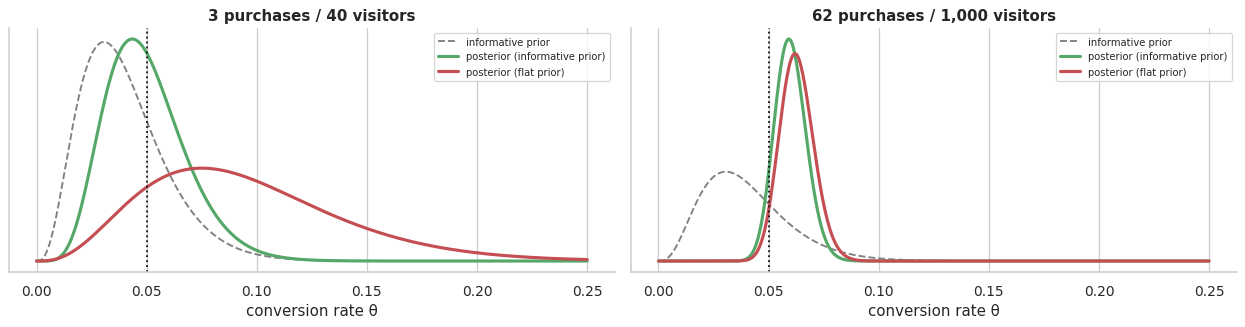

In [3]:
def summarise(k, n):
    rows = {}
    for name, (a, b) in [("informative Beta(4, 96)", prior_inf), ("flat Beta(1, 1)", prior_flat)]:
        post = stats.beta(a + k, b + n - k); lo, hi = post.ppf([.025, .975])
        rows[name] = {"posterior mean": post.mean(), "2.5 %": lo, "97.5 %": hi, "P(θ > 5 %)": post.sf(.05)}
    lo, hi = proportion_confint(k, n, method="wilson"); rows["frequentist (Wilson)"] = {"posterior mean": k / n, "2.5 %": lo, "97.5 %": hi, "P(θ > 5 %)": np.nan}
    return pd.DataFrame(rows).T.round(3)
for label, (k, n) in [("after 2 days: 3 / 40", early), ("after 3 weeks: 62 / 1000", later)]:
    print(label); print(summarise(k, n), "\n")

x = np.linspace(0, .25, 600); fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), sharex=True)
for ax, (k, n), title in zip(axes, [early, later], ["3 purchases / 40 visitors", "62 purchases / 1,000 visitors"]):
    ax.plot(x, stats.beta.pdf(x, *prior_inf), color="grey", ls="--", label="informative prior")
    ax.plot(x, stats.beta.pdf(x, prior_inf[0] + k, prior_inf[1] + n - k), color=C[2], lw=2.5, label="posterior (informative prior)")
    ax.plot(x, stats.beta.pdf(x, 1 + k, 1 + n - k), color=C[3], lw=2.5, label="posterior (flat prior)"); ax.axvline(.05, color="k", ls=":")
    ax.set(title=title, xlabel="conversion rate θ", yticks=[]); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation.** After two days the data are worth 40 observations, the informative prior 100 — so the prior dominates: the posterior mean is 5.0 % rather than 7.5 %, and the probability that the product beats 5 % is only a coin flip (≈ 45 %), not the near-certainty suggested by the flat-prior analysis (≈ 85 %) or by the raw number. The Wilson interval (≈ 2.6 %–19.9 %) is honest about the uncertainty but cannot use what the team already knows.

After three weeks the two posteriors almost coincide (means 6.0 % vs. 6.3 %) and *both* say with high probability that the rate exceeds 5 %: **the data have overwhelmed the prior**. The product really is better than past launches — but the first read-out exaggerated by how much.

**For investors:** the informative analysis. "Extraordinary early numbers" from tiny samples are mostly noise; shrinking them towards experience protects against the winner's curse (Module 8). Showing both priors side by side is the honest way to communicate how much of the conclusion is data and how much is assumption.

### ✍️ Exercise 12.2 — *Bayesian A/B test*: Which subject line goes to the full mailing list? (CRM)

Two e-mail subject lines were sent to 4,000 recipients each. Clicks: **A 184, B 221**. The winner will be sent to 500,000 customers. Marketing will switch to B if the *expected loss* of doing so is below **0.05 percentage points** of click rate.

**Tasks**
1. With Beta(1, 1) priors, draw 400,000 samples from each posterior. Compute $P(\theta_B>\theta_A)$.
2. Report the posterior median and 95 % credible interval of the relative lift.
3. Compute the expected loss of choosing B and of choosing A. What is the decision?
4. Run the frequentist two-proportion $z$-test on the same data. Put the two conclusions side by side: do they conflict?

In [4]:
n_A, k_A, n_B, k_B = 4000, 184, 4000, 221
g = np.random.default_rng(1202)

click rates: A 4.60%, B 5.53%
P(B > A | data) = 0.970
relative lift: median +20.0%, 95 % CrI [-0.7%, +45.3%]
expected loss: choose B -> 0.0057 pp,  choose A -> 0.9301 pp   (tolerance 0.05 pp)
frequentist z-test: z = 1.89, p = 0.059


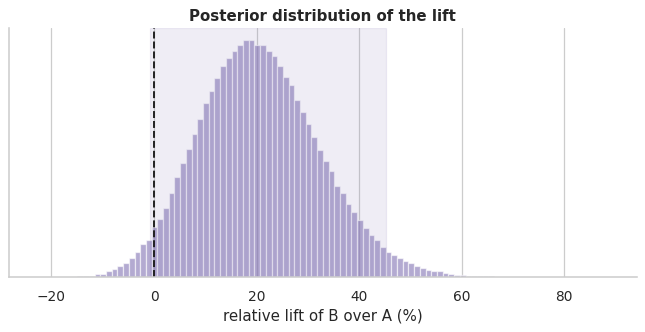

In [5]:
A = stats.beta.rvs(1 + k_A, 1 + n_A - k_A, size=400_000, random_state=g); B = stats.beta.rvs(1 + k_B, 1 + n_B - k_B, size=400_000, random_state=g)
lift = B / A - 1; lo, hi = np.quantile(lift, [.025, .975])
loss_B, loss_A = np.maximum(A - B, 0).mean() * 100, np.maximum(B - A, 0).mean() * 100
z, p = proportions_ztest([k_B, k_A], [n_B, n_A])
print(f"click rates: A {k_A / n_A:.2%}, B {k_B / n_B:.2%}")
print(f"P(B > A | data) = {(B > A).mean():.3f}")
print(f"relative lift: median {np.median(lift):+.1%}, 95 % CrI [{lo:+.1%}, {hi:+.1%}]")
print(f"expected loss: choose B -> {loss_B:.4f} pp,  choose A -> {loss_A:.4f} pp   (tolerance 0.05 pp)")
print(f"frequentist z-test: z = {z:.2f}, p = {p:.3f}")
fig, ax = plt.subplots(figsize=(9, 3.6)); ax.hist(lift * 100, bins=100, color=C[4], alpha=.6); ax.axvline(0, color="k", ls="--"); ax.axvspan(lo * 100, hi * 100, color=C[4], alpha=.12)
ax.set(xlabel="relative lift of B over A (%)", yticks=[], title="Posterior distribution of the lift"); plt.show()

**Interpretation.** B is better than A with a posterior probability of about **97 %**; the lift is most plausibly around +20 %, with a credible interval from roughly −1 % to +45 %. The expected loss of choosing B is tiny (≈ 0.006 pp — far below the 0.05 pp tolerance), whereas sticking with A would forgo about 0.9 pp on average. **Decision: send B.**

The frequentist test gives $p\approx0.06$ — "not significant at 5 %". There is no contradiction: the p-value says that data this extreme would occur in 6 % of experiments *if the lines were identical*; the posterior says that *given these data* B is very probably better. For a low-stakes, reversible choice between two subject lines, demanding 95 % confidence before acting would be the wrong standard — the expected-loss rule weighs what is actually at stake.

### ✍️ Exercise 12.3 — *Gamma–Poisson & posterior prediction*: Sizing the on-call team (IT operations)

A platform team took over a service twelve weeks ago. Weekly numbers of major incidents are given below. Similar services in the company average about 3 incidents per week, which the team encodes as a Gamma(6, 2) prior (mean 3, worth two weeks of data). The on-call rota can absorb **up to 5 incidents per week**.

**Tasks**
1. Compute the posterior of the incident rate $\lambda$ with a 95 % credible interval. Plot prior and posterior.
2. Compute the posterior predictive probability of **6 or more incidents next week**, and compare with the plug-in Poisson($\hat\lambda$) answer.
3. How many overload weeks should the team expect in the coming quarter (13 weeks)?
4. Check the predictive distribution by simulation (draw $\lambda$, then $y$).

In [6]:
incidents = np.array([2, 4, 1, 3, 5, 2, 2, 6, 3, 1, 4, 3])
alpha0, beta0 = 6, 2
g = np.random.default_rng(1203)

posterior: Gamma(42, 14),  mean = 3.00 per week,  95 % CrI [2.16, 3.97]
P(6+ incidents next week): posterior predictive 0.091   vs. plug-in Poisson 0.084
expected overload weeks per quarter: 1.2
simulation check: P(6+) = 0.090


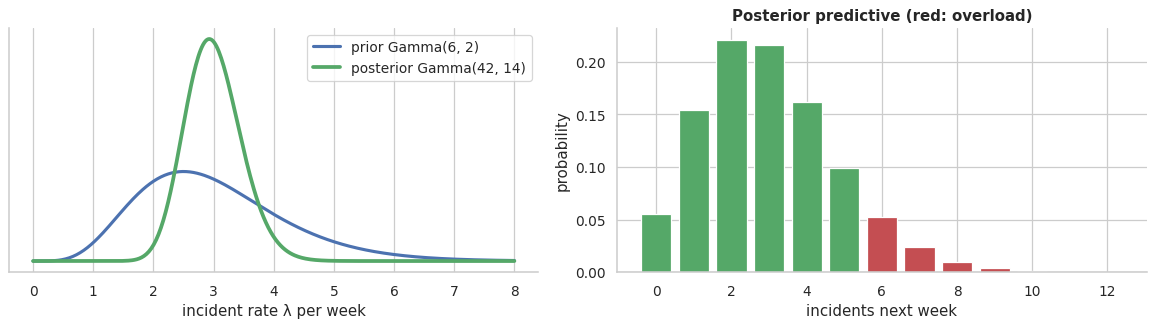

In [7]:
alpha1, beta1 = alpha0 + incidents.sum(), beta0 + incidents.size
post = stats.gamma(alpha1, scale=1 / beta1); lo, hi = post.ppf([.025, .975])
print(f"posterior: Gamma({alpha1}, {beta1}),  mean = {post.mean():.2f} per week,  95 % CrI [{lo:.2f}, {hi:.2f}]")
p_pred = stats.nbinom.sf(5, alpha1, beta1 / (beta1 + 1)); p_plug = stats.poisson.sf(5, incidents.mean())
print(f"P(6+ incidents next week): posterior predictive {p_pred:.3f}   vs. plug-in Poisson {p_plug:.3f}")
print(f"expected overload weeks per quarter: {13 * p_pred:.1f}")
sim = g.poisson(g.gamma(alpha1, 1 / beta1, 500_000)); print(f"simulation check: P(6+) = {(sim >= 6).mean():.3f}")

lam = np.linspace(0, 8, 400); k = np.arange(0, 13); fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.8))
a1.plot(lam, stats.gamma.pdf(lam, alpha0, scale=1 / beta0), color=C[0], lw=2.5, label="prior Gamma(6, 2)"); a1.plot(lam, post.pdf(lam), color=C[2], lw=3, label=f"posterior Gamma({alpha1}, {beta1})"); a1.set(xlabel="incident rate λ per week", yticks=[]); a1.legend()
a2.bar(k, stats.nbinom.pmf(k, alpha1, beta1 / (beta1 + 1)), color=[C[3] if v >= 6 else C[2] for v in k]); a2.set(xlabel="incidents next week", ylabel="probability", title="Posterior predictive (red: overload)"); plt.tight_layout(); plt.show()

**Interpretation.** Twelve weeks with 36 incidents, combined with the prior, give a posterior Gamma(42, 14): about **3.0 incidents per week**, 95 % credible interval ≈ 2.2–4.0. The probability that next week exceeds the rota's capacity is about **9 %**; the plug-in Poisson, which ignores the uncertainty about $\lambda$, says ≈ 8 % — the predictive distribution has the heavier tail, as it should. Over a quarter the team should expect **one to two overload weeks**.

**Decision support:** whether ~1.2 overload weeks per quarter are acceptable is a management question, but it is now a *quantified* one. Here prior and data happen to agree, so the prior hardly moves the estimate — it mainly mattered in the first weeks, when there was almost no data.

### ✍️ Exercise 12.4 — *Shrinkage*: Which seller deserves the "top-rated" badge? (Online marketplace)

A marketplace ranks sellers by their share of positive reviews. Established sellers' true rates are well described by a Beta(36, 4) distribution (mean 90 %).

**Tasks**
1. Rank the eight sellers by their raw positive rate. What is odd about the top of the list?
2. Compute each seller's posterior mean and the **5 % posterior quantile** (a "pessimistic score": we are 95 % sure the true rate is higher). Rank by both.
3. Seller E (3/3) or seller D (940/1000) — compute the posterior probability that E's true rate is higher than D's.
4. Which ranking rule would you implement, and why?

In [8]:
sellers = pd.DataFrame({"seller": list("ABCDEFGH"), "positive": [10, 48, 186, 940, 3, 27, 450, 88], "reviews": [10, 50, 200, 1000, 3, 30, 500, 100]}).set_index("seller")
a0, b0 = 36, 4
g = np.random.default_rng(1204)

        positive  reviews  raw rate  posterior mean  5 % quantile  \
seller                                                              
D            940     1000      0.94           0.938         0.926   
C            186      200      0.93           0.925         0.895   
B             48       50      0.96           0.933         0.886   
G            450      500      0.90           0.900         0.878   
A             10       10      1.00           0.920         0.849   
H             88      100      0.88           0.886         0.839   
F             27       30      0.90           0.900         0.836   
E              3        3      1.00           0.907         0.826   

        rank by raw rate  rank by posterior mean  rank by 5 % quantile  
seller                                                                  
D                      4                       1                     1  
C                      5                       3                     2  
B                


P(true rate of E > true rate of D) = 0.26


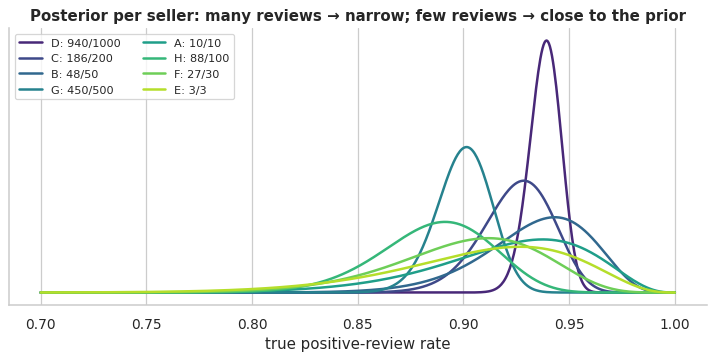

In [9]:
s = sellers.copy(); s["raw rate"] = s.positive / s.reviews
s["posterior mean"] = (a0 + s.positive) / (a0 + b0 + s.reviews)
s["5 % quantile"] = stats.beta.ppf(.05, a0 + s.positive, b0 + s.reviews - s.positive)
for col in ["raw rate", "posterior mean", "5 % quantile"]: s[f"rank by {col}"] = s[col].rank(ascending=False).astype(int)
print(s.round(3).sort_values("rank by 5 % quantile"))
E = stats.beta.rvs(a0 + 3, b0 + 0, size=300_000, random_state=g); D = stats.beta.rvs(a0 + 940, b0 + 60, size=300_000, random_state=g)
print(f"\nP(true rate of E > true rate of D) = {(E > D).mean():.2f}")
xg = np.linspace(.7, 1, 600); fig, ax = plt.subplots(figsize=(10, 4))
for (name, r), col in zip(s.sort_values("rank by 5 % quantile").iterrows(), sns.color_palette("viridis", 8)):
    ax.plot(xg, stats.beta.pdf(xg, a0 + r["positive"], b0 + r["reviews"] - r["positive"]), color=col, lw=2, label=f"{name}: {r['positive']:.0f}/{r['reviews']:.0f}")
ax.set(xlabel="true positive-review rate", yticks=[], title="Posterior per seller: many reviews → narrow; few reviews → close to the prior"); ax.legend(ncol=2, fontsize=9); plt.show()

**Interpretation.** By raw rate the podium belongs to sellers **A (10/10)** and **E (3/3)** — a "perfect" 100 % from a handful of reviews — ahead of seller D with 940 positive reviews out of 1,000. With so little data, 100 % says almost nothing: a typical 90 % seller produces three positive reviews in a row 73 % of the time.

The **posterior mean** pulls A and E back towards the platform average of 90 %; the **pessimistic score** (5 % quantile) additionally penalises uncertainty, and now the large, proven sellers D, B and C lead. Is E better than D? The posterior probability is only about 26 % — three reviews cannot outweigh a thousand, which is exactly why E should not outrank D.

**Recommendation:** rank by a lower posterior quantile. It rewards a high rate *and* evidence, lets new sellers climb quickly as reviews arrive, and cannot be gamed with three friendly reviews. (Several large platforms rank by such lower bounds — frequentist cousins use the lower Wilson limit.)

### ✍️ Exercise 12.5 — *MCMC*: The Challenger O-ring data (Engineering risk, real data)

On 28 January 1986 the space shuttle *Challenger* was launched at **31 °F**, far colder than any previous launch, and was destroyed when an O-ring seal failed. Below are the 23 earlier flights with the launch temperature and whether O-ring damage was observed. Model: logistic regression $\text{logit}\,P(\text{damage})=\alpha+\beta\cdot(T-70)/10$ with weak N(0, 5²) priors.

**Tasks**
1. Code the log-posterior and sample it with the `metropolis` function (30,000 iterations; discard 3,000 as burn-in). Report the acceptance rate and inspect the trace plots.
2. What is the posterior probability that damage becomes *less* likely with rising temperature ($\beta<0$)?
3. Plot the data with 200 posterior curves and the posterior-mean curve from 30 to 85 °F.
4. Give the posterior median and 95 % credible interval of $P(\text{damage})$ at 31 °F. Cross-check $\hat\alpha,\hat\beta$ with a maximum-likelihood fit.
5. The engineers had no data below 53 °F. How should that affect the way you present the result?

In [10]:
temp = np.array([66, 70, 69, 68, 67, 72, 73, 70, 57, 63, 70, 78, 67, 53, 67, 75, 70, 81, 76, 79, 75, 76, 58])
damage = np.array([0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1])
g = np.random.default_rng(1205)

def metropolis(log_post, start, step, n_iter, rng):                     # the sampler from section 8, repeated so that the exercise is self-contained
    chain = np.empty((n_iter, len(start))); current = np.asarray(start, float); lp = log_post(current); accepted = 0
    for i in range(n_iter):
        proposal = current + rng.normal(0, step, size=current.size); lp_new = log_post(proposal)
        if np.log(rng.random()) < lp_new - lp: current, lp = proposal, lp_new; accepted += 1
        chain[i] = current
    return chain, accepted / n_iter

acceptance rate = 41%;  posterior means: alpha = -1.33, beta = -2.75;  P(beta < 0 | data) = 0.999
maximum likelihood: alpha = -1.21, beta = -2.32
P(damage at 31 °F): posterior median = 1.000, 95 % CrI [0.891, 1.000]


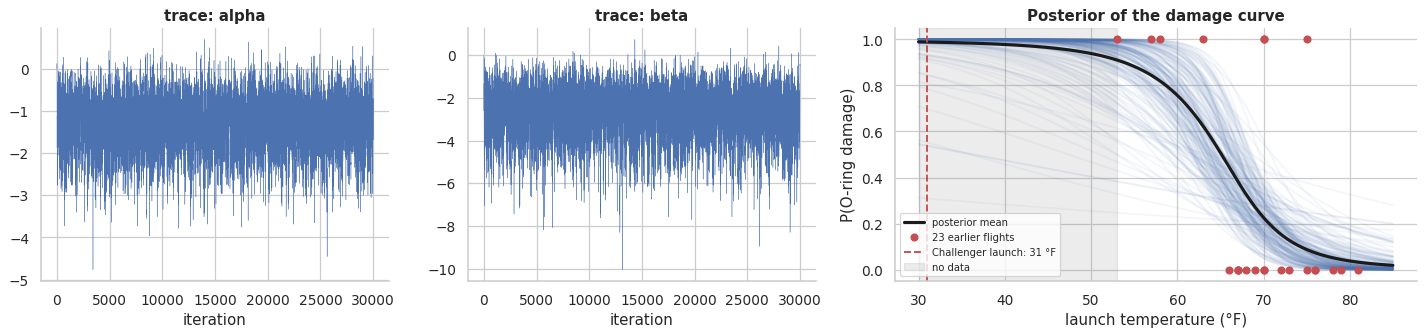

In [11]:
x = (temp - 70) / 10
def log_post(theta):
    eta = theta[0] + theta[1] * x
    return (damage * eta - np.log1p(np.exp(eta))).sum() - (theta ** 2).sum() / (2 * 5 ** 2)      # Bernoulli log-likelihood + N(0, 5²) priors

chain, acc = metropolis(log_post, start=[0., 0.], step=[.9, 1.5], n_iter=30_000, rng=g); post = chain[3000:]
alpha, beta = post.T; sig = lambda z: 1 / (1 + np.exp(-z))
p31 = sig(alpha + beta * (31 - 70) / 10)
print(f"acceptance rate = {acc:.0%};  posterior means: alpha = {alpha.mean():.2f}, beta = {beta.mean():.2f};  P(beta < 0 | data) = {(beta < 0).mean():.3f}")
mle = smf.logit("damage ~ x", pd.DataFrame({"damage": damage, "x": x})).fit(disp=0); print(f"maximum likelihood: alpha = {mle.params.iloc[0]:.2f}, beta = {mle.params.iloc[1]:.2f}")
print(f"P(damage at 31 °F): posterior median = {np.median(p31):.3f}, 95 % CrI [{np.quantile(p31, .025):.3f}, {np.quantile(p31, .975):.3f}]")

tt = np.linspace(30, 85, 200); xt = (tt - 70) / 10
fig, axes = plt.subplots(1, 3, figsize=(16, 3.9), gridspec_kw={"width_ratios": [1, 1, 1.5]})
axes[0].plot(chain[:, 0], lw=.3, color=C[0]); axes[0].set(title="trace: alpha", xlabel="iteration"); axes[1].plot(chain[:, 1], lw=.3, color=C[0]); axes[1].set(title="trace: beta", xlabel="iteration")
for i in g.choice(post.shape[0], 200, replace=False): axes[2].plot(tt, sig(post[i, 0] + post[i, 1] * xt), color=C[0], alpha=.06)
axes[2].plot(tt, sig(alpha[:, None] + beta[:, None] * xt).mean(axis=0), color="k", lw=2.5, label="posterior mean"); axes[2].scatter(temp, damage, color=C[3], zorder=3, s=30, label="23 earlier flights")
axes[2].axvline(31, color=C[3], ls="--", label="Challenger launch: 31 °F"); axes[2].axvspan(30, 53, color="grey", alpha=.15, label="no data"); axes[2].set(xlabel="launch temperature (°F)", ylabel="P(O-ring damage)", title="Posterior of the damage curve"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation.** The trace plots are stationary and the acceptance rate lies in the healthy range; the posterior means are close to the maximum-likelihood estimates (a little more extreme, because the posterior is skewed — the ML estimate corresponds to its *mode*). The probability that the temperature effect is negative is about **99.9 %**: the colder the launch, the likelier the damage. At 31 °F the posterior median of $P(\text{damage})$ is close to **1**, and even the lower end of the 95 % credible interval is far above the damage rates seen on warm days.

**Honest presentation:** 31 °F lies 22 °F below the coldest flight on record — a massive **extrapolation** (Module 9). The width of the posterior band in the grey zone reflects only *parameter* uncertainty *within* the logistic model; whether a logistic curve holds down there cannot be checked with these data. But that caveat cuts the right way: every curve compatible with the data points upwards in the cold, and "we have never tested this regime and all evidence indicates rising risk" was, by itself, a sufficient argument not to launch. The famous failure on the eve of the launch was partly a failure of statistical graphics — the charts shown to the decision makers omitted the flights *without* damage, hiding the temperature pattern that your plot shows at a glance.